# CSC2042S Assignment 1
## Perceptron Image Classification

**Student:** Liso Njena  
**Student number:** NJNLIS001

This notebook implements a multi-class perceptron from scratch and applies it to the Simpsons-MNIST dataset. Explanations are included before each code section so that the design and results can be understood and reproduced.

# Task 1: Data processing

The perceptron cannot work directly with JPEG files. The images must first be loaded into NumPy arrays and paired with numeric class labels.

This section:

1. Loads the grayscale and RGB training and test images with Pillow.
2. Preserves the raw, unflattened pixel arrays for later data augmentation.
3. Splits only the supplied training set into training and validation subsets.
4. Uses the same split for RGB and grayscale images so that the comparison is fair.
5. Flattens images into feature vectors and provides the three normalisation options required later.

The supplied test set is kept separate. It must not be used to select hyperparameters.

## 1.1 Imports and reproducibility

- `Path` constructs file paths that work across operating systems.
- NumPy stores images and performs numerical calculations.
- Pillow opens and converts the JPEG images.
- Matplotlib displays samples for a visual data check.
- `train_test_split` creates a stratified training/validation split.
- A fixed random seed ensures that the same split can be reproduced.

In [30]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
from sklearn.model_selection import train_test_split

RANDOM_SEED = 42

## 1.2 Class labels

The dataset stores each character in a separate folder. A perceptron requires numeric targets, so every folder name is mapped to one label from 0 to 9. The ordering below follows the dataset's documented label mapping.

In [31]:
CLASS_NAMES = [
    "bart_simpson",
    "charles_montgomery_burns",
    "homer_simpson",
    "krusty_the_clown",
    "lisa_simpson",
    "marge_simpson",
    "milhouse_van_houten",
    "moe_szyslak",
    "ned_flanders",
    "principal_skinner",
]

CLASS_TO_LABEL = {
    class_name: label
    for label, class_name in enumerate(CLASS_NAMES)
}

LABEL_TO_CLASS = {
    label: class_name
    for class_name, label in CLASS_TO_LABEL.items()
}

CLASS_TO_LABEL

{'bart_simpson': 0,
 'charles_montgomery_burns': 1,
 'homer_simpson': 2,
 'krusty_the_clown': 3,
 'lisa_simpson': 4,
 'marge_simpson': 5,
 'milhouse_van_houten': 6,
 'moe_szyslak': 7,
 'ned_flanders': 8,
 'principal_skinner': 9}

## 1.3 Loading JPEG images

The loader visits the ten character folders in a fixed order and sorts the filenames. Sorting makes the loading order reproducible and keeps corresponding RGB and grayscale images aligned.

Pillow mode `"L"` produces a grayscale array of shape `(28, 28)`. Mode `"RGB"` produces an RGB array of shape `(28, 28, 3)`.

Raw pixels are stored as `np.uint8`, whose values range from 0 to 255. The images are not flattened or normalised inside this function because the raw image shape is required for the augmentation experiments in Task 7.

In [32]:
def load_dataset(split_directory, image_mode):
    """Load one train/test directory into raw image and label arrays.

    Parameters
    ----------
    split_directory : str or Path
        Directory containing one subfolder per Simpsons character.
    image_mode : {"L", "RGB"}
        Pillow colour mode. "L" loads grayscale; "RGB" loads colour.

    Returns
    -------
    images : np.ndarray
        Raw uint8 images. Shape is (N, 28, 28) for grayscale or
        (N, 28, 28, 3) for RGB.
    labels : np.ndarray
        Integer class labels with shape (N,).
    image_ids : list[str]
        Relative identifiers used to verify RGB/grayscale alignment.
    """
    split_directory = Path(split_directory)

    if image_mode == "L":
        expected_shape = (28, 28)
    elif image_mode == "RGB":
        expected_shape = (28, 28, 3)
    else:
        raise ValueError("image_mode must be either 'L' or 'RGB'")

    images = []
    labels = []
    image_ids = []

    for label, class_name in enumerate(CLASS_NAMES):
        class_directory = split_directory / class_name

        if not class_directory.is_dir():
            raise FileNotFoundError(
                f"Class folder not found: {class_directory}"
            )

        image_paths = sorted(
            path
            for path in class_directory.iterdir()
            if path.suffix.lower() in {".jpg", ".jpeg"}
        )

        if not image_paths:
            raise FileNotFoundError(
                f"No JPEG images found in: {class_directory}"
            )

        for image_path in image_paths:
            # The context manager closes the image file after it is read.
            with Image.open(image_path) as image:
                image_array = np.asarray(
                    image.convert(image_mode),
                    dtype=np.uint8,
                )

            if image_array.shape != expected_shape:
                raise ValueError(
                    f"{image_path} has shape {image_array.shape}; "
                    f"expected {expected_shape}"
                )

            images.append(image_array)
            labels.append(label)
            image_ids.append(f"{class_name}/{image_path.name}")

    return (
        np.stack(images),
        np.asarray(labels, dtype=np.int64),
        image_ids,
    )

## 1.4 Locating the dataset

The local dataset folder is named `A2-dataset` and is deliberately ignored by Git because the assignment says not to submit the data.

The second condition below also supports the structure obtained by cloning the original Simpsons-MNIST repository, where the `grayscale` and `rgb` folders are nested inside another folder named `dataset`.

In [33]:
DATA_ROOT = Path("A2-dataset")

# Support A2-dataset/dataset/grayscale/... as well as
# A2-dataset/grayscale/...
if (DATA_ROOT / "dataset").is_dir():
    DATA_ROOT = DATA_ROOT / "dataset"

required_directories = [
    DATA_ROOT / "grayscale" / "train",
    DATA_ROOT / "grayscale" / "test",
    DATA_ROOT / "rgb" / "train",
    DATA_ROOT / "rgb" / "test",
]

missing_directories = [
    path for path in required_directories
    if not path.is_dir()
]

if missing_directories:
    missing_text = "\n".join(str(path) for path in missing_directories)
    raise FileNotFoundError(
        "The following dataset directories were not found:\n"
        f"{missing_text}\n\n"
        "Check that A2-dataset is extracted and that the notebook "
        "is being run from the repository folder."
    )

print("Working directory:", Path.cwd())
print("Dataset directory:", DATA_ROOT.resolve())

Working directory: C:\Users\Liso\Documents\GitHub\Assignment-AI
Dataset directory: C:\Users\Liso\Documents\GitHub\Assignment-AI\A2-dataset\dataset


## 1.5 Loading the four supplied sets

The supplied training images are called the *full training set* here because they will shortly be divided into a smaller training set and a held-out validation set.

The supplied test set is loaded but will remain untouched during model development and hyperparameter tuning.

In [34]:
X_gray_full_raw, y_gray_full, gray_train_ids = load_dataset(
    DATA_ROOT / "grayscale" / "train",
    image_mode="L",
)

X_rgb_full_raw, y_rgb_full, rgb_train_ids = load_dataset(
    DATA_ROOT / "rgb" / "train",
    image_mode="RGB",
)

X_gray_test_raw, y_gray_test, gray_test_ids = load_dataset(
    DATA_ROOT / "grayscale" / "test",
    image_mode="L",
)

X_rgb_test_raw, y_rgb_test, rgb_test_ids = load_dataset(
    DATA_ROOT / "rgb" / "test",
    image_mode="RGB",
)

print("All four datasets loaded successfully.")

All four datasets loaded successfully.


## 1.6 Verifying the loaded data

These assertions are deliberate correctness checks:

- Both modalities must contain corresponding images in the same order.
- Their labels must agree.
- Grayscale and RGB arrays must have the expected dimensions.
- The official dataset should contain 8,000 supplied training images and 2,000 test images.

If an assertion fails, the data-loading problem should be fixed before training a model.

In [35]:
assert gray_train_ids == rgb_train_ids
assert gray_test_ids == rgb_test_ids
assert np.array_equal(y_gray_full, y_rgb_full)
assert np.array_equal(y_gray_test, y_rgb_test)

assert X_gray_full_raw.shape == (8000, 28, 28)
assert X_rgb_full_raw.shape == (8000, 28, 28, 3)
assert X_gray_test_raw.shape == (2000, 28, 28)
assert X_rgb_test_raw.shape == (2000, 28, 28, 3)

print("Grayscale supplied training:", X_gray_full_raw.shape)
print("RGB supplied training:      ", X_rgb_full_raw.shape)
print("Grayscale test:             ", X_gray_test_raw.shape)
print("RGB test:                   ", X_rgb_test_raw.shape)
print("Raw pixel data type:        ", X_rgb_full_raw.dtype)
print("Raw pixel range:            ",
      X_rgb_full_raw.min(), "to", X_rgb_full_raw.max())

Grayscale supplied training: (8000, 28, 28)
RGB supplied training:       (8000, 28, 28, 3)
Grayscale test:              (2000, 28, 28)
RGB test:                    (2000, 28, 28, 3)
Raw pixel data type:         uint8
Raw pixel range:             0 to 255


## 1.7 Visual inspection

A visual check helps catch incorrect labels, colour modes, or corrupted images. The following cell displays one RGB example from each class.

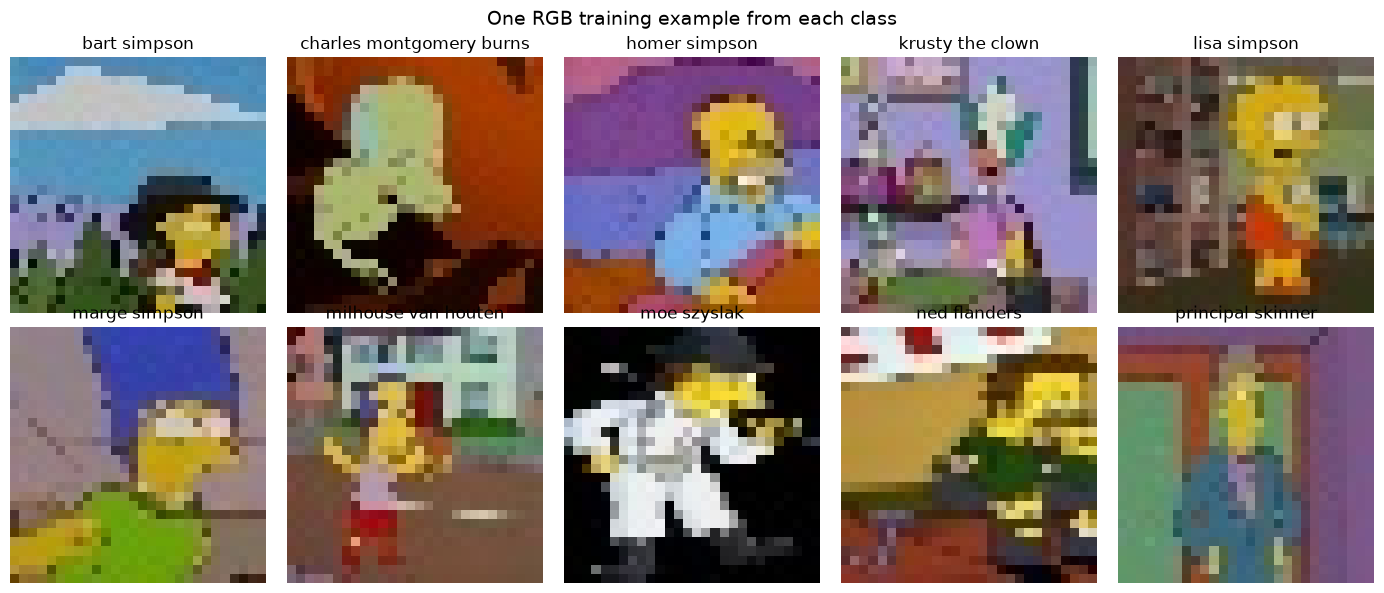

In [36]:
fig, axes = plt.subplots(2, 5, figsize=(14, 6))

for label, axis in enumerate(axes.flat):
    example_index = np.flatnonzero(y_rgb_full == label)[0]
    axis.imshow(X_rgb_full_raw[example_index])
    axis.set_title(CLASS_NAMES[label].replace("_", " "))
    axis.axis("off")

fig.suptitle("One RGB training example from each class", fontsize=14)
plt.tight_layout()
plt.show()

## 1.8 Training/validation split

The supplied training set is divided into 80% training data and 20% validation data:

- Training: 6,400 images
- Validation: 1,600 images
- Test: the original 2,000 images

A **stratified** split preserves the proportion of all ten classes. The split is performed on indices and the same indices are applied to RGB and grayscale arrays. This ensures that both modalities are trained and validated on corresponding examples.

The validation set will guide hyperparameter selection. The test set must only be used for the final evaluation.

In [37]:
all_indices = np.arange(y_gray_full.shape[0])

train_indices, validation_indices = train_test_split(
    all_indices,
    test_size=0.20,
    random_state=RANDOM_SEED,
    stratify=y_gray_full,
)

# Grayscale split
X_gray_train_raw = X_gray_full_raw[train_indices]
X_gray_validation_raw = X_gray_full_raw[validation_indices]

# RGB split using exactly the same image indices
X_rgb_train_raw = X_rgb_full_raw[train_indices]
X_rgb_validation_raw = X_rgb_full_raw[validation_indices]

# Labels are shared because RGB and grayscale images are aligned.
y_train = y_gray_full[train_indices]
y_validation = y_gray_full[validation_indices]
y_test = y_gray_test.copy()

print("Training labels:  ", y_train.shape)
print("Validation labels:", y_validation.shape)
print("Test labels:      ", y_test.shape)

Training labels:   (6400,)
Validation labels: (1600,)
Test labels:       (2000,)


## 1.9 Checking class balance

The dataset is balanced, and stratification should preserve this balance. Printing the counts verifies that each character is properly represented in every split.

In [38]:
def class_counts(labels):
    """Return the number of examples belonging to each class."""
    return np.bincount(labels, minlength=len(CLASS_NAMES))


train_counts = class_counts(y_train)
validation_counts = class_counts(y_validation)
test_counts = class_counts(y_test)

print(f"{'Class':32s} {'Train':>7s} {'Validation':>12s} {'Test':>7s}")
print("-" * 62)

for label, class_name in enumerate(CLASS_NAMES):
    print(
        f"{class_name:32s} "
        f"{train_counts[label]:7d} "
        f"{validation_counts[label]:12d} "
        f"{test_counts[label]:7d}"
    )

Class                              Train   Validation    Test
--------------------------------------------------------------
bart_simpson                         640          160     200
charles_montgomery_burns             640          160     200
homer_simpson                        640          160     200
krusty_the_clown                     640          160     200
lisa_simpson                         640          160     200
marge_simpson                        640          160     200
milhouse_van_houten                  640          160     200
moe_szyslak                          640          160     200
ned_flanders                         640          160     200
principal_skinner                    640          160     200


## 1.10 Flattening and normalisation

A perceptron expects each example to be a one-dimensional feature vector.

- Grayscale: `(28, 28) -> (784,)`
- RGB: `(28, 28, 3) -> (2352,)`

The function below supports the three preprocessing conditions required for hyperparameter tuning:

- `"none"`: retain pixel values from 0 to 255.
- `"zero_one"`: divide pixels by 255 to obtain values from 0 to 1.
- `"z_score"`: subtract the training mean and divide by the training standard deviation.

For z-score normalisation, statistics are calculated **only from the training set** and then applied to validation and test data. Calculating them using validation or test data would cause data leakage.

In [39]:
def preprocess_splits(
    train_images,
    validation_images,
    test_images,
    method="none",
):
    """Flatten and consistently normalise train/validation/test images."""
    # Convert uint8 pixels to float32 before arithmetic.
    train = train_images.reshape(train_images.shape[0], -1).astype(np.float32)
    validation = validation_images.reshape(
        validation_images.shape[0], -1
    ).astype(np.float32)
    test = test_images.reshape(test_images.shape[0], -1).astype(np.float32)

    if method == "none":
        return train, validation, test

    if method == "zero_one":
        return train / 255.0, validation / 255.0, test / 255.0

    if method == "z_score":
        # Each flattened pixel position is treated as one feature.
        feature_mean = train.mean(axis=0, keepdims=True)
        feature_std = train.std(axis=0, keepdims=True)

        # Constant features have standard deviation zero. Dividing them
        # by 1 instead prevents division-by-zero without changing them.
        safe_std = np.where(feature_std < 1e-8, 1.0, feature_std)

        return (
            (train - feature_mean) / safe_std,
            (validation - feature_mean) / safe_std,
            (test - feature_mean) / safe_std,
        )

    raise ValueError(
        "method must be 'none', 'zero_one', or 'z_score'"
    )

## 1.11 Preparing the initial feature arrays

For the initial implementation, no normalisation is applied. Task 4 will systematically compare this baseline with 0-to-1 scaling and z-score normalisation.

The expected final feature shapes are:

- Grayscale training: `(6400, 784)`
- RGB training: `(6400, 2352)`

In [40]:
X_gray_train, X_gray_validation, X_gray_test = preprocess_splits(
    X_gray_train_raw,
    X_gray_validation_raw,
    X_gray_test_raw,
    method="none",
)

X_rgb_train, X_rgb_validation, X_rgb_test = preprocess_splits(
    X_rgb_train_raw,
    X_rgb_validation_raw,
    X_rgb_test_raw,
    method="none",
)

print("Grayscale features:")
print("  Train:     ", X_gray_train.shape)
print("  Validation:", X_gray_validation.shape)
print("  Test:      ", X_gray_test.shape)

print("\nRGB features:")
print("  Train:     ", X_rgb_train.shape)
print("  Validation:", X_rgb_validation.shape)
print("  Test:      ", X_rgb_test.shape)

Grayscale features:
  Train:      (6400, 784)
  Validation: (1600, 784)
  Test:       (2000, 784)

RGB features:
  Train:      (6400, 2352)
  Validation: (1600, 2352)
  Test:       (2000, 2352)


## Task 1 summary

The JPEG files have now been transformed into data suitable for a perceptron:

- All images have numeric labels from 0 to 9.
- Raw arrays are retained for the later augmentation task.
- The supplied training set is split reproducibly and stratified by class.
- RGB and grayscale models use corresponding train/validation examples.
- Each image can be flattened and processed using any required normalisation method.
- Training-derived statistics are used to avoid validation/test leakage.
- The test set remains reserved for final evaluation.

# Task 2: Multi-class perceptron implementation

The assignment requires an object-oriented implementation built from scratch with NumPy.

Two classes are used:

1. `BinaryPerceptron` learns whether an image belongs to one particular class. Its prediction is either 0 or 1.
2. `MultiClassPerceptron` contains ten binary perceptrons and uses one-vs-rest classification to predict one label from 0 to 9.

Task 2 defines the model and its update operations. The full epoch-based training loop is implemented separately in Task 3.

## 2.1 Binary perceptron

For one flattened image vector \(x\), the binary perceptron calculates

\[
z = w \cdot x + b
\]

and applies the threshold

\[
\hat{y} =
\begin{cases}
1 & \text{if } z \geq 0 \\
0 & \text{if } z < 0
\end{cases}
\]

The required initial value of every weight and the bias is 0.1.

When the prediction is incorrect, the perceptron learning rule is

\[
e = y - \hat{y}
\]

\[
w \leftarrow w + \eta e x
\]

\[
b \leftarrow b + \eta e
\]

where \(\eta\) is the learning rate.

In [41]:
class BinaryPerceptron:
    """Binary perceptron that predicts either 0 or 1."""

    def __init__(self, n_features, learning_rate=0.01):
        if n_features <= 0:
            raise ValueError("n_features must be positive")

        if learning_rate <= 0:
            raise ValueError("learning_rate must be positive")

        self.n_features = int(n_features)
        self.learning_rate = float(learning_rate)

        # The assignment requires every weight and the bias to start at 0.1.
        self.weights = np.full(
            self.n_features,
            0.1,
            dtype=np.float32,
        )
        self.bias = 0.1

    def _validate_input(self, x):
        """Convert one example to float32 and check its feature shape."""
        x = np.asarray(x, dtype=np.float32)

        if x.shape != (self.n_features,):
            raise ValueError(
                f"Expected one vector with shape ({self.n_features},), "
                f"but received {x.shape}"
            )

        return x

    def score(self, x):
        """Return the unthresholded score w dot x + b."""
        x = self._validate_input(x)
        return float(np.dot(self.weights, x) + self.bias)

    def predict(self, x):
        """Return 1 when the score is non-negative; otherwise return 0."""
        return int(self.score(x) >= 0.0)

    def update(self, x, target):
        """Apply one perceptron update and return the prediction error."""
        if target not in (0, 1):
            raise ValueError("A binary target must be either 0 or 1")

        x = self._validate_input(x)
        prediction = self.predict(x)
        error = int(target) - prediction

        # When error is zero, these parameters already give the right label.
        if error != 0:
            self.weights += self.learning_rate * error * x
            self.bias += self.learning_rate * error

        return error

## 2.2 Checking one binary update

A small artificial vector makes the learning rule easy to verify by hand. Initially:

\[
w = [0.1, 0.1, 0.1], \quad b = 0.1
\]

For \(x=[1,-2,0.5]\), the initial score is 0.05, so the prediction is 1. If the correct target is 0, the error is \(-1\), causing the weights and bias to decrease or increase according to each input value.

In [42]:
demo_binary = BinaryPerceptron(
    n_features=3,
    learning_rate=0.1,
)

demo_x = np.array([1.0, -2.0, 0.5], dtype=np.float32)

print("Initial weights:   ", demo_binary.weights)
print("Initial bias:      ", demo_binary.bias)
print("Initial score:     ", demo_binary.score(demo_x))
print("Initial prediction:", demo_binary.predict(demo_x))

demo_error = demo_binary.update(demo_x, target=0)

print("\nError:             ", demo_error)
print("Updated weights:   ", demo_binary.weights)
print("Updated bias:      ", demo_binary.bias)
print("Updated prediction:", demo_binary.predict(demo_x))

assert np.allclose(
    demo_binary.weights,
    np.array([0.0, 0.3, 0.05], dtype=np.float32),
)
assert np.isclose(demo_binary.bias, 0.0)
assert demo_binary.predict(demo_x) == 0

print("\nBinary update check passed.")

Initial weights:    [0.1 0.1 0.1]
Initial bias:       0.1
Initial score:      0.05000000074505806
Initial prediction: 1

Error:              -1
Updated weights:    [0.   0.3  0.05]
Updated bias:       0.0
Updated prediction: 0

Binary update check passed.


## 2.3 Extending binary classification with one-vs-rest

One binary perceptron cannot directly choose among ten characters. The multi-class model therefore creates ten separate binary problems.

For an image whose true class is Lisa Simpson (class 4), the ten binary targets are

\[
[0,0,0,0,1,0,0,0,0,0]
\]

- Lisa's perceptron is trained with target 1: "Lisa".
- Every other perceptron is trained with target 0: "not this character".

For prediction, all ten perceptrons return their raw scores:

\[
[s_0,s_1,\ldots,s_9]
\]

The model selects the position of the largest score using \`argmax\`.

In [43]:
class MultiClassPerceptron:
    """Ten one-vs-rest binary perceptrons for multi-class prediction."""

    def __init__(
        self,
        n_features,
        n_classes=10,
        learning_rate=0.01,
    ):
        if n_classes < 2:
            raise ValueError("n_classes must be at least 2")

        self.n_features = int(n_features)
        self.n_classes = int(n_classes)
        self.learning_rate = float(learning_rate)

        # All binary models receive the same hyperparameter settings.
        self.perceptrons = [
            BinaryPerceptron(
                n_features=self.n_features,
                learning_rate=self.learning_rate,
            )
            for _ in range(self.n_classes)
        ]

    @property
    def weights(self):
        """Return all binary weight vectors as a (K, n_features) matrix."""
        return np.stack([
            perceptron.weights
            for perceptron in self.perceptrons
        ])

    @property
    def biases(self):
        """Return all binary biases as a vector of shape (K,)."""
        return np.asarray([
            perceptron.bias
            for perceptron in self.perceptrons
        ], dtype=np.float32)

    def _validate_input(self, x):
        """Check one flattened image vector."""
        x = np.asarray(x, dtype=np.float32)

        if x.shape != (self.n_features,):
            raise ValueError(
                f"Expected one vector with shape ({self.n_features},), "
                f"but received {x.shape}"
            )

        return x

    def scores(self, x):
        """Return the ten one-vs-rest scores for one image."""
        x = self._validate_input(x)
        return self.weights @ x + self.biases

    def predict(self, x):
        """Return the class label with the greatest score."""
        return int(np.argmax(self.scores(x)))

    def predict_many(self, X):
        """Efficiently predict the labels of a matrix of image vectors."""
        X = np.asarray(X, dtype=np.float32)

        if X.ndim != 2 or X.shape[1] != self.n_features:
            raise ValueError(
                f"Expected shape (N, {self.n_features}), "
                f"but received {X.shape}"
            )

        all_scores = X @ self.weights.T + self.biases
        return np.argmax(all_scores, axis=1)

    def update(self, x, true_class):
        """Train every one-vs-rest perceptron on one labelled image."""
        if not 0 <= int(true_class) < self.n_classes:
            raise ValueError(
                f"true_class must be from 0 to {self.n_classes - 1}"
            )

        x = self._validate_input(x)
        errors = np.empty(self.n_classes, dtype=np.int8)

        for class_label, perceptron in enumerate(self.perceptrons):
            # Only the correct class receives target 1.
            binary_target = int(class_label == int(true_class))
            errors[class_label] = perceptron.update(
                x,
                binary_target,
            )

        return errors

## 2.4 Verifying the multi-class structure

A grayscale image has 784 features. Therefore, ten grayscale binary perceptrons collectively contain a weight matrix of shape `(10, 784)` and a bias vector of shape `(10,)`.

Because all parameters initially equal 0.1, all ten models initially produce the same score for the same image. NumPy's `argmax` resolves this initial tie by returning the first position, class 0. Training will cause the ten parameter sets to become different.

In [44]:
demo_multiclass = MultiClassPerceptron(
    n_features=784,
    n_classes=len(CLASS_NAMES),
    learning_rate=0.01,
)

demo_gray_image = np.zeros(784, dtype=np.float32)
demo_scores = demo_multiclass.scores(demo_gray_image)

print("Number of binary perceptrons:",
      len(demo_multiclass.perceptrons))
print("Weight matrix shape:        ",
      demo_multiclass.weights.shape)
print("Bias vector shape:          ",
      demo_multiclass.biases.shape)
print("Score vector shape:         ",
      demo_scores.shape)
print("Initial scores:             ",
      demo_scores)
print("Initial predicted class:    ",
      demo_multiclass.predict(demo_gray_image))

assert len(demo_multiclass.perceptrons) == 10
assert demo_multiclass.weights.shape == (10, 784)
assert demo_multiclass.biases.shape == (10,)
assert demo_scores.shape == (10,)
assert demo_multiclass.predict(demo_gray_image) == 0

print("\nMulti-class structure check passed.")

Number of binary perceptrons: 10
Weight matrix shape:         (10, 784)
Bias vector shape:           (10,)
Score vector shape:          (10,)
Initial scores:              [0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1]
Initial predicted class:     0

Multi-class structure check passed.


## Task 2 summary

The model now satisfies the required object-oriented structure:

- `BinaryPerceptron` has one weight per input feature and one bias.
- Every weight and bias is initialised to 0.1.
- Its `predict` method returns either 0 or 1.
- Its `update` method implements the perceptron learning rule.
- `MultiClassPerceptron` owns ten binary perceptron objects.
- Each training image generates one positive and nine negative binary targets.
- Multi-class prediction selects the greatest of the ten raw scores.
- The grayscale weight matrix has shape `(10, 784)`; RGB will use `(10, 2352)`.

The next task will repeatedly shuffle the training examples, call `update` one image at a time, record validation accuracy, and implement stopping criteria.

# Task 3: Training

The perceptron parameters only become useful after repeatedly processing labelled training images.

An **epoch** means one complete pass through all 6,400 training examples. The data are not divided between epochs: every epoch uses the complete training set. At the beginning of each epoch, the order of the examples is shuffled.

For each image, the training loop:

1. Calculates the current multi-class prediction.
2. Compares it with the correct class.
3. Converts the correct class into ten one-vs-rest binary targets.
4. Updates all ten binary perceptrons using that single image.
5. Continues until every training image has been processed.

After the epoch, the updated model is evaluated on the complete training and validation sets.

## 3.1 Stopping criteria

The assignment asks us to investigate at least two stopping criteria.

### Fixed number of epochs

Training always completes a predetermined number of epochs. It is simple and predictable, but it may stop too early or continue after validation performance has stopped improving.

### Early stopping on validation accuracy

The validation accuracy is checked after every epoch. When it fails to improve meaningfully for a chosen number of consecutive epochs, training stops. The parameter controlling this waiting period is called **patience**.

The best-performing validation model is saved and restored, rather than returning the parameters from a later, worse epoch.

### Error threshold

The implementation also supports stopping when the online training error rate becomes smaller than a selected threshold:

\[
\text{online error rate}
=
\frac{\text{incorrect multi-class predictions during the epoch}}
{\text{number of training examples}}
\]

This criterion may never be reached because the Simpsons images are unlikely to be perfectly linearly separable.

## 3.2 Accuracy helper

The model’s `predict_many` method predicts a complete feature matrix efficiently. Accuracy is the proportion of predicted labels that equal the correct labels.

In [45]:
def classification_accuracy(model, X, y):
    """Return the proportion of correctly classified examples."""
    predictions = model.predict_many(X)
    return float(np.mean(predictions == y))

## 3.3 Epoch-based training function

The function below constructs a fresh model for every experiment. This is important: two experimental runs must not share weights learned in an earlier run.

A local NumPy random generator shuffles the indices reproducibly. Shuffling indices is more memory-efficient than repeatedly copying every image.

The function records:

- Online training errors encountered while parameters are changing.
- Training accuracy after the epoch.
- Validation accuracy after the epoch.
- Elapsed runtime.
- The best validation epoch and the reason training stopped.

In [46]:
from copy import deepcopy
from time import perf_counter


def train_multiclass_perceptron(
    X_train,
    y_train,
    X_validation,
    y_validation,
    learning_rate=0.01,
    max_epochs=20,
    stopping_criterion="fixed_epochs",
    error_threshold=0.0,
    patience=3,
    min_delta=1e-4,
    random_seed=RANDOM_SEED,
    verbose=True,
):
    """Train a fresh one-vs-rest multi-class perceptron.

    Parameters
    ----------
    stopping_criterion : {"fixed_epochs", "early_stopping",
                          "error_threshold"}
        Rule used to decide when training should finish.
    error_threshold : float
        Maximum online error rate accepted by the error-threshold rule.
    patience : int
        Number of non-improving epochs allowed by early stopping.
    min_delta : float
        Smallest validation-accuracy increase counted as improvement.

    Returns
    -------
    model : MultiClassPerceptron
        The trained model. For early stopping, this is the model from
        the best validation epoch.
    history : dict
        Measurements collected after every completed epoch.
    """
    valid_criteria = {
        "fixed_epochs",
        "early_stopping",
        "error_threshold",
    }

    if stopping_criterion not in valid_criteria:
        raise ValueError(
            f"stopping_criterion must be one of {valid_criteria}"
        )

    if max_epochs <= 0:
        raise ValueError("max_epochs must be positive")

    if patience <= 0:
        raise ValueError("patience must be positive")

    if not 0.0 <= error_threshold <= 1.0:
        raise ValueError("error_threshold must be between 0 and 1")

    X_train = np.asarray(X_train, dtype=np.float32)
    X_validation = np.asarray(X_validation, dtype=np.float32)
    y_train = np.asarray(y_train, dtype=np.int64)
    y_validation = np.asarray(y_validation, dtype=np.int64)

    if X_train.ndim != 2 or X_validation.ndim != 2:
        raise ValueError("Feature arrays must be two-dimensional")

    if X_train.shape[1] != X_validation.shape[1]:
        raise ValueError(
            "Training and validation feature counts must match"
        )

    if X_train.shape[0] != y_train.shape[0]:
        raise ValueError("Training features and labels must align")

    if X_validation.shape[0] != y_validation.shape[0]:
        raise ValueError("Validation features and labels must align")

    model = MultiClassPerceptron(
        n_features=X_train.shape[1],
        n_classes=len(CLASS_NAMES),
        learning_rate=learning_rate,
    )

    # This generator produces the same shuffle sequence for the same seed.
    rng = np.random.default_rng(random_seed)

    history = {
        "epoch": [],
        "online_errors": [],
        "online_error_rate": [],
        "training_accuracy": [],
        "validation_accuracy": [],
        "elapsed_seconds": [],
    }

    best_validation_accuracy = -np.inf
    best_epoch = 0
    best_model = deepcopy(model)
    epochs_without_improvement = 0
    stopping_reason = "Maximum epochs reached"

    start_time = perf_counter()

    for epoch in range(1, max_epochs + 1):
        shuffled_indices = rng.permutation(X_train.shape[0])
        online_errors = 0

        for index in shuffled_indices:
            x = X_train[index]
            true_class = int(y_train[index])

            # This prediction is made before the parameters are updated.
            prediction = model.predict(x)
            online_errors += int(prediction != true_class)

            # Every image trains all ten one-vs-rest classifiers.
            model.update(x, true_class)

        online_error_rate = online_errors / X_train.shape[0]

        # These accuracies use the model after completing the epoch.
        training_accuracy = classification_accuracy(
            model,
            X_train,
            y_train,
        )
        validation_accuracy = classification_accuracy(
            model,
            X_validation,
            y_validation,
        )

        history["epoch"].append(epoch)
        history["online_errors"].append(online_errors)
        history["online_error_rate"].append(online_error_rate)
        history["training_accuracy"].append(training_accuracy)
        history["validation_accuracy"].append(validation_accuracy)
        history["elapsed_seconds"].append(
            perf_counter() - start_time
        )

        improved = (
            validation_accuracy
            > best_validation_accuracy + min_delta
        )

        if improved:
            best_validation_accuracy = validation_accuracy
            best_epoch = epoch
            best_model = deepcopy(model)
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1

        if verbose:
            print(
                f"Epoch {epoch:2d}/{max_epochs}: "
                f"online errors = {online_errors:4d}, "
                f"train accuracy = {training_accuracy:.4f}, "
                f"validation accuracy = {validation_accuracy:.4f}"
            )

        if (
            stopping_criterion == "error_threshold"
            and online_error_rate <= error_threshold
        ):
            stopping_reason = (
                f"Online error rate reached {error_threshold:.4f}"
            )
            break

        if (
            stopping_criterion == "early_stopping"
            and epochs_without_improvement >= patience
        ):
            stopping_reason = (
                f"Validation accuracy did not improve for "
                f"{patience} epochs"
            )
            break

    history["best_epoch"] = best_epoch
    history["best_validation_accuracy"] = (
        best_validation_accuracy
    )
    history["epochs_completed"] = len(history["epoch"])
    history["stopping_reason"] = stopping_reason

    if stopping_criterion == "early_stopping":
        # Return the best validation model, not the final attempted epoch.
        model = best_model

    if verbose:
        print(
            f"Stopped after {history['epochs_completed']} epochs: "
            f"{stopping_reason}"
        )
        print(
            f"Best validation accuracy: "
            f"{best_validation_accuracy:.4f} "
            f"at epoch {best_epoch}"
        )

    return model, history

## 3.4 Plotting training history

The curves help us see whether learning is improving, unstable, or beginning to overfit. A large and growing gap between training and validation accuracy could indicate overfitting.

In [47]:
def plot_training_history(history, title):
    """Plot accuracy and online error rate across epochs."""
    epochs = history["epoch"]

    fig, axes = plt.subplots(1, 2, figsize=(13, 4))

    axes[0].plot(
        epochs,
        history["training_accuracy"],
        marker="o",
        label="Training accuracy",
    )
    axes[0].plot(
        epochs,
        history["validation_accuracy"],
        marker="o",
        label="Validation accuracy",
    )
    axes[0].axvline(
        history["best_epoch"],
        color="black",
        linestyle="--",
        alpha=0.6,
        label="Best validation epoch",
    )
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Accuracy")
    axes[0].set_ylim(0.0, 1.0)
    axes[0].set_title("Accuracy")
    axes[0].legend()
    axes[0].grid(alpha=0.3)

    axes[1].plot(
        epochs,
        history["online_error_rate"],
        marker="o",
        color="tab:red",
    )
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Online error rate")
    axes[1].set_ylim(0.0, 1.0)
    axes[1].set_title("Errors encountered during training")
    axes[1].grid(alpha=0.3)

    fig.suptitle(title)
    plt.tight_layout()
    plt.show()

## 3.5 Baseline data for the stopping-criterion experiment

This initial experiment uses grayscale images normalised from 0 to 1. It is only a controlled baseline for comparing training procedures; Task 4 will systematically tune learning rate and normalisation for both grayscale and RGB.

Both stopping-criterion runs below use the same learning rate, data split, and random seed. Therefore, their only meaningful difference is when they stop.

In [48]:
(
    X_gray_train_baseline,
    X_gray_validation_baseline,
    X_gray_test_baseline,
) = preprocess_splits(
    X_gray_train_raw,
    X_gray_validation_raw,
    X_gray_test_raw,
    method="zero_one",
)

print("Baseline training shape:  ",
      X_gray_train_baseline.shape)
print("Baseline validation shape:",
      X_gray_validation_baseline.shape)

Baseline training shape:   (6400, 784)
Baseline validation shape: (1600, 784)


## 3.6 Stopping criterion 1: fixed epochs

This model always completes exactly ten epochs, regardless of whether validation accuracy has already stopped improving.

Epoch  1/10: online errors = 5484, train accuracy = 0.1948, validation accuracy = 0.1681
Epoch  2/10: online errors = 5285, train accuracy = 0.1234, validation accuracy = 0.1219
Epoch  3/10: online errors = 5166, train accuracy = 0.2741, validation accuracy = 0.1981
Epoch  4/10: online errors = 5043, train accuracy = 0.2308, validation accuracy = 0.1725
Epoch  5/10: online errors = 4964, train accuracy = 0.2964, validation accuracy = 0.2062
Epoch  6/10: online errors = 4949, train accuracy = 0.3197, validation accuracy = 0.2106
Epoch  7/10: online errors = 4921, train accuracy = 0.2159, validation accuracy = 0.1500
Epoch  8/10: online errors = 4829, train accuracy = 0.2002, validation accuracy = 0.1619
Epoch  9/10: online errors = 4733, train accuracy = 0.2391, validation accuracy = 0.1700
Epoch 10/10: online errors = 4780, train accuracy = 0.3089, validation accuracy = 0.2131
Stopped after 10 epochs: Maximum epochs reached
Best validation accuracy: 0.2131 at epoch 10


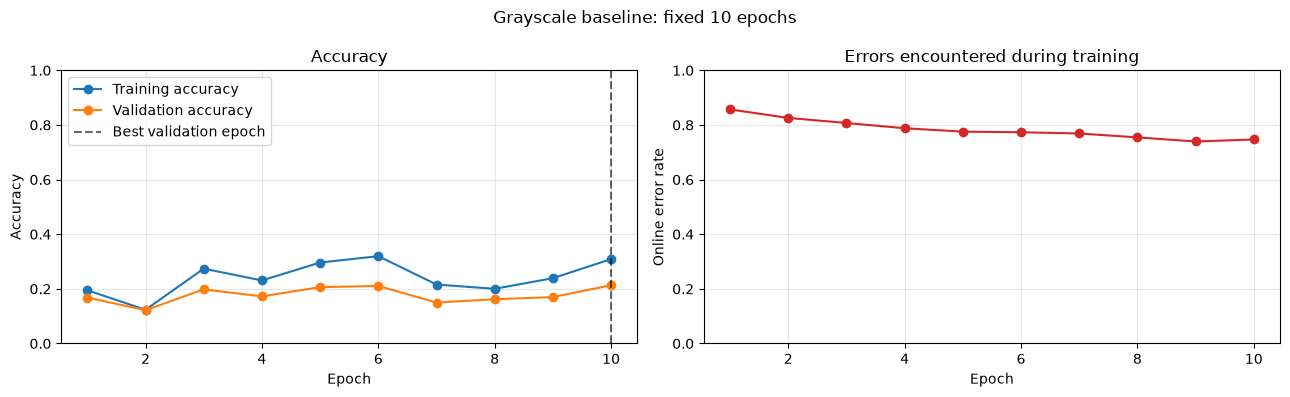

In [49]:
fixed_model, fixed_history = train_multiclass_perceptron(
    X_train=X_gray_train_baseline,
    y_train=y_train,
    X_validation=X_gray_validation_baseline,
    y_validation=y_validation,
    learning_rate=0.01,
    max_epochs=10,
    stopping_criterion="fixed_epochs",
    random_seed=RANDOM_SEED,
)

plot_training_history(
    fixed_history,
    title="Grayscale baseline: fixed 10 epochs",
)

## 3.7 Stopping criterion 2: early stopping

This model may train for at most 30 epochs, but it stops after validation accuracy fails to improve for three consecutive epochs. The parameters from the best validation epoch are restored.

Epoch  1/30: online errors = 5484, train accuracy = 0.1948, validation accuracy = 0.1681
Epoch  2/30: online errors = 5285, train accuracy = 0.1234, validation accuracy = 0.1219
Epoch  3/30: online errors = 5166, train accuracy = 0.2741, validation accuracy = 0.1981
Epoch  4/30: online errors = 5043, train accuracy = 0.2308, validation accuracy = 0.1725
Epoch  5/30: online errors = 4964, train accuracy = 0.2964, validation accuracy = 0.2062
Epoch  6/30: online errors = 4949, train accuracy = 0.3197, validation accuracy = 0.2106
Epoch  7/30: online errors = 4921, train accuracy = 0.2159, validation accuracy = 0.1500
Epoch  8/30: online errors = 4829, train accuracy = 0.2002, validation accuracy = 0.1619
Epoch  9/30: online errors = 4733, train accuracy = 0.2391, validation accuracy = 0.1700
Stopped after 9 epochs: Validation accuracy did not improve for 3 epochs
Best validation accuracy: 0.2106 at epoch 6


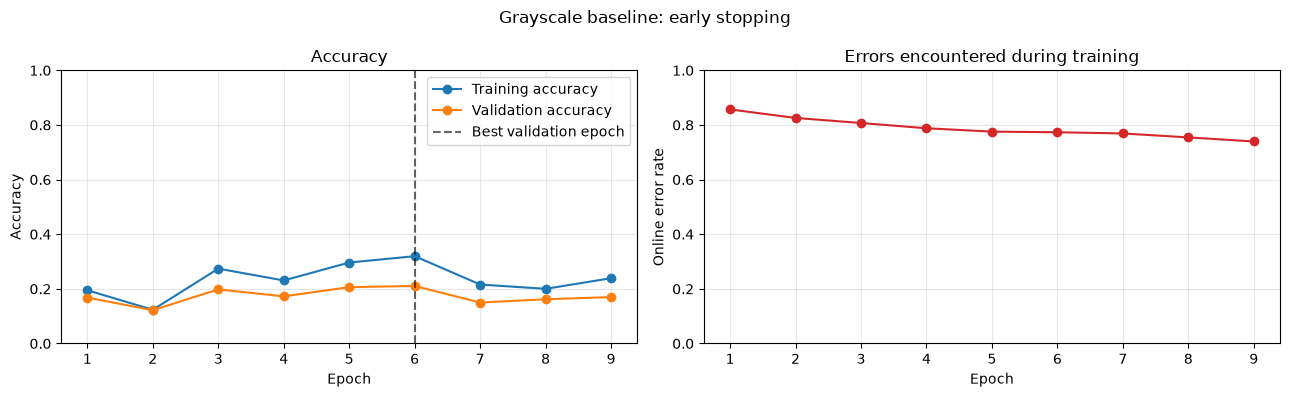

In [50]:
early_model, early_history = train_multiclass_perceptron(
    X_train=X_gray_train_baseline,
    y_train=y_train,
    X_validation=X_gray_validation_baseline,
    y_validation=y_validation,
    learning_rate=0.01,
    max_epochs=30,
    stopping_criterion="early_stopping",
    patience=3,
    min_delta=1e-4,
    random_seed=RANDOM_SEED,
)

plot_training_history(
    early_history,
    title="Grayscale baseline: early stopping",
)

## 3.8 Comparing the stopping criteria

The comparison considers:

- How many epochs were completed.
- The best validation accuracy reached.
- Runtime.
- The reason training stopped.

Early stopping is effective when it reaches comparable or better validation accuracy using fewer epochs. Fixed epochs may be preferable when a known training budget is required, but its chosen limit must be justified.

In [51]:
def print_training_comparison(named_histories):
    """Print a compact comparison of training runs."""
    header = (
        f"{'Run':24s} "
        f"{'Epochs':>7s} "
        f"{'Best epoch':>11s} "
        f"{'Best val.':>10s} "
        f"{'Seconds':>10s}"
    )
    print(header)
    print("-" * len(header))

    for name, history in named_histories.items():
        print(
            f"{name:24s} "
            f"{history['epochs_completed']:7d} "
            f"{history['best_epoch']:11d} "
            f"{history['best_validation_accuracy']:10.4f} "
            f"{history['elapsed_seconds'][-1]:10.2f}"
        )
        print(f"  Stop reason: {history['stopping_reason']}")


print_training_comparison({
    "Fixed 10 epochs": fixed_history,
    "Early stopping": early_history,
})

Run                       Epochs  Best epoch  Best val.    Seconds
------------------------------------------------------------------
Fixed 10 epochs               10          10     0.2131       2.96
  Stop reason: Maximum epochs reached
Early stopping                 9           6     0.2106       2.64
  Stop reason: Validation accuracy did not improve for 3 epochs


## 3.9 Stopping-criterion discussion

The fixed-epoch rule guarantees a known number of passes through the data, but the number ten is an external choice rather than evidence that the model has finished improving.

Early stopping responds to the observed validation performance. It can reduce unnecessary computation and restores the parameters from the strongest validation epoch. However, its behaviour depends on the patience and minimum-improvement settings, and normal fluctuations in perceptron accuracy may cause it to stop prematurely.

The printed results and plots above provide the evidence needed to compare the two criteria. Their actual accuracy, epoch count, and runtime will be reported after executing the notebook.

## Task 3 summary

The training procedure now:

- Uses every training example once per epoch.
- Shuffles the complete training set between epochs.
- Updates the ten binary perceptrons one image at a time.
- Measures training and validation accuracy after each epoch.
- Records errors, runtime, and convergence history.
- Supports fixed epochs, validation-based early stopping, and an error threshold.
- Applies and compares fixed epochs and early stopping under controlled baseline settings.

Task 4 will reuse this training function to tune learning rate and normalisation separately for grayscale and RGB.

# Task 4: Hyperparameter tuning

The assignment requires separate tuning experiments for grayscale and RGB inputs. Two hyperparameters are varied systematically:

1. The perceptron learning rate, \(\eta\).
2. The input normalisation method: no normalisation, scaling to 0-1, or z-score normalisation.

Every configuration is selected using validation accuracy only. The test set is not transformed, predicted, or inspected anywhere in this section.

## 4.1 Controlled experiment design

The learning-rate grid spans four orders of magnitude:

\[
\eta \in \{10^{-4}, 10^{-3}, 10^{-2}, 10^{-1}\}
\]

This wide range is useful because raw pixels range from 0 to 255, whereas normalised inputs have a much smaller scale. A learning rate that works well for one input scale may be unstable or ineffective for another.

For a fair comparison:

- Each configuration creates a fresh model whose weights and biases start at 0.1.
- All ten binary perceptrons use the same learning rate and normalisation.
- Every run receives the same training/validation split and the same epoch shuffle sequence.
- Validation-based early stopping uses a maximum of 20 epochs and patience of 4.
- The test set remains completely untouched.
- A validation-accuracy tie is resolved in favour of the run that required fewer epochs.

In [52]:
LEARNING_RATES = [1e-4, 1e-3, 1e-2, 1e-1]
NORMALISATION_METHODS = ["none", "zero_one", "z_score"]

NORMALISATION_LABELS = {
    "none": "None",
    "zero_one": "0-1 scaling",
    "z_score": "Z-score",
}

TUNING_MAX_EPOCHS = 20
TUNING_PATIENCE = 4

print("Learning rates:", LEARNING_RATES)
print("Normalisation methods:", NORMALISATION_METHODS)

Learning rates: [0.0001, 0.001, 0.01, 0.1]
Normalisation methods: ['none', 'zero_one', 'z_score']


## 4.2 Training/validation preprocessing

This helper prepares only the training and validation arrays. It deliberately does not accept the test set, preventing accidental use of test information during tuning.

For z-score normalisation, the mean and standard deviation are calculated from the training set only and then applied to validation data. This prevents data leakage.

In [53]:
def preprocess_train_validation(
    train_images,
    validation_images,
    method,
):
    """Flatten and normalise training/validation images without test data."""
    train = train_images.reshape(
        train_images.shape[0], -1
    ).astype(np.float32)

    validation = validation_images.reshape(
        validation_images.shape[0], -1
    ).astype(np.float32)

    if method == "none":
        return train, validation

    if method == "zero_one":
        return train / 255.0, validation / 255.0

    if method == "z_score":
        # Fit normalisation statistics on training features only.
        feature_mean = train.mean(axis=0, keepdims=True)
        feature_std = train.std(axis=0, keepdims=True)
        safe_std = np.where(feature_std < 1e-8, 1.0, feature_std)

        return (
            (train - feature_mean) / safe_std,
            (validation - feature_mean) / safe_std,
        )

    raise ValueError(
        "method must be 'none', 'zero_one', or 'z_score'"
    )

## 4.3 Grid-search function

For each normalisation method, the raw images are preprocessed once and reused across the four learning rates. The function trains twelve models for one modality and records:

- Best validation accuracy.
- Epoch containing the best validation result.
- Total epochs completed before stopping.
- Final online error rate.
- Runtime.
- The trained best-epoch model and its complete history.

The model and history are retained so that Task 5 can evaluate the selected configuration without retraining or using the test set prematurely.

In [54]:
def run_hyperparameter_grid(
    modality_name,
    train_images,
    validation_images,
    y_train,
    y_validation,
    learning_rates=LEARNING_RATES,
    normalisation_methods=NORMALISATION_METHODS,
    max_epochs=TUNING_MAX_EPOCHS,
    patience=TUNING_PATIENCE,
    random_seed=RANDOM_SEED,
):
    """Tune one modality using validation accuracy only."""
    results = []

    total_runs = len(learning_rates) * len(normalisation_methods)
    run_number = 0

    print(f"\nTuning {modality_name}: {total_runs} configurations")

    for method in normalisation_methods:
        X_train_processed, X_validation_processed = (
            preprocess_train_validation(
                train_images,
                validation_images,
                method=method,
            )
        )

        for learning_rate in learning_rates:
            run_number += 1

            model, history = train_multiclass_perceptron(
                X_train=X_train_processed,
                y_train=y_train,
                X_validation=X_validation_processed,
                y_validation=y_validation,
                learning_rate=learning_rate,
                max_epochs=max_epochs,
                stopping_criterion="early_stopping",
                patience=patience,
                min_delta=0.0,
                random_seed=random_seed,
                verbose=False,
            )

            result = {
                "modality": modality_name,
                "normalisation": method,
                "learning_rate": float(learning_rate),
                "best_validation_accuracy": (
                    history["best_validation_accuracy"]
                ),
                "best_epoch": history["best_epoch"],
                "epochs_completed": history["epochs_completed"],
                "final_online_error_rate": (
                    history["online_error_rate"][-1]
                ),
                "elapsed_seconds": history["elapsed_seconds"][-1],
                "model": model,
                "history": history,
            }
            results.append(result)

            print(
                f"[{run_number:2d}/{total_runs}] "
                f"{NORMALISATION_LABELS[method]:12s} | "
                f"eta={learning_rate:<7g} | "
                f"best val={result['best_validation_accuracy']:.4f} | "
                f"best epoch={result['best_epoch']:2d} | "
                f"ran {result['epochs_completed']:2d} epochs"
            )

    return results


def print_tuning_table(results):
    """Print comparable measurements for every grid-search run."""
    header = (
        f"{'Normalisation':14s} "
        f"{'Learning rate':>13s} "
        f"{'Best val.':>10s} "
        f"{'Best epoch':>11s} "
        f"{'Epochs run':>11s} "
        f"{'Final error':>12s} "
        f"{'Seconds':>9s}"
    )

    print(header)
    print("-" * len(header))

    for result in results:
        print(
            f"{NORMALISATION_LABELS[result['normalisation']]:14s} "
            f"{result['learning_rate']:13g} "
            f"{result['best_validation_accuracy']:10.4f} "
            f"{result['best_epoch']:11d} "
            f"{result['epochs_completed']:11d} "
            f"{result['final_online_error_rate']:12.4f} "
            f"{result['elapsed_seconds']:9.2f}"
        )

## 4.4 Grayscale grid search

This cell trains the twelve grayscale configurations. It may take a little time because every run processes the complete 6,400-image training set for several epochs.

In [55]:
gray_tuning_results = run_hyperparameter_grid(
    modality_name="Grayscale",
    train_images=X_gray_train_raw,
    validation_images=X_gray_validation_raw,
    y_train=y_train,
    y_validation=y_validation,
)

print("\nGrayscale tuning results")
print_tuning_table(gray_tuning_results)


Tuning Grayscale: 12 configurations
[ 1/12] None         | eta=0.0001  | best val=0.2137 | best epoch= 8 | ran 12 epochs
[ 2/12] None         | eta=0.001   | best val=0.2400 | best epoch=13 | ran 17 epochs
[ 3/12] None         | eta=0.01    | best val=0.2269 | best epoch= 8 | ran 12 epochs
[ 4/12] None         | eta=0.1     | best val=0.2069 | best epoch= 5 | ran  9 epochs
[ 5/12] 0-1 scaling  | eta=0.0001  | best val=0.2506 | best epoch= 4 | ran  8 epochs
[ 6/12] 0-1 scaling  | eta=0.001   | best val=0.2362 | best epoch= 8 | ran 12 epochs
[ 7/12] 0-1 scaling  | eta=0.01    | best val=0.2206 | best epoch=13 | ran 17 epochs
[ 8/12] 0-1 scaling  | eta=0.1     | best val=0.2213 | best epoch= 5 | ran  9 epochs
[ 9/12] Z-score      | eta=0.0001  | best val=0.2619 | best epoch= 2 | ran  6 epochs
[10/12] Z-score      | eta=0.001   | best val=0.2325 | best epoch= 9 | ran 13 epochs
[11/12] Z-score      | eta=0.01    | best val=0.2206 | best epoch= 5 | ran  9 epochs
[12/12] Z-score      | eta=0

## 4.5 RGB grid search

The same grid and shuffle seed are now applied to RGB inputs. The RGB vectors contain 2,352 features rather than 784, so these runs may take longer than the grayscale runs.

In [56]:
rgb_tuning_results = run_hyperparameter_grid(
    modality_name="RGB",
    train_images=X_rgb_train_raw,
    validation_images=X_rgb_validation_raw,
    y_train=y_train,
    y_validation=y_validation,
)

print("\nRGB tuning results")
print_tuning_table(rgb_tuning_results)


Tuning RGB: 12 configurations
[ 1/12] None         | eta=0.0001  | best val=0.4138 | best epoch=14 | ran 18 epochs
[ 2/12] None         | eta=0.001   | best val=0.3894 | best epoch= 3 | ran  7 epochs
[ 3/12] None         | eta=0.01    | best val=0.3844 | best epoch= 7 | ran 11 epochs
[ 4/12] None         | eta=0.1     | best val=0.3594 | best epoch= 3 | ran  7 epochs
[ 5/12] 0-1 scaling  | eta=0.0001  | best val=0.4275 | best epoch= 8 | ran 12 epochs
[ 6/12] 0-1 scaling  | eta=0.001   | best val=0.4106 | best epoch=12 | ran 16 epochs
[ 7/12] 0-1 scaling  | eta=0.01    | best val=0.3756 | best epoch= 4 | ran  8 epochs
[ 8/12] 0-1 scaling  | eta=0.1     | best val=0.4219 | best epoch=14 | ran 18 epochs
[ 9/12] Z-score      | eta=0.0001  | best val=0.3956 | best epoch= 2 | ran  6 epochs
[10/12] Z-score      | eta=0.001   | best val=0.3906 | best epoch=17 | ran 20 epochs
[11/12] Z-score      | eta=0.01    | best val=0.3337 | best epoch= 2 | ran  6 epochs
[12/12] Z-score      | eta=0.1    

## 4.6 Performance and convergence plots

Each modality receives three complementary plots:

1. Validation performance: how the best validation accuracy changes with learning rate under each normalisation method.
2. Training duration: how many epochs each configuration completed before early stopping.
3. Convergence history: validation accuracy across epochs for the strongest learning rate found under each normalisation method.

Together these show both final performance and training stability/convergence. The performance axes use a data-dependent range so small but genuine differences remain visible; the numerical table above provides the exact values.

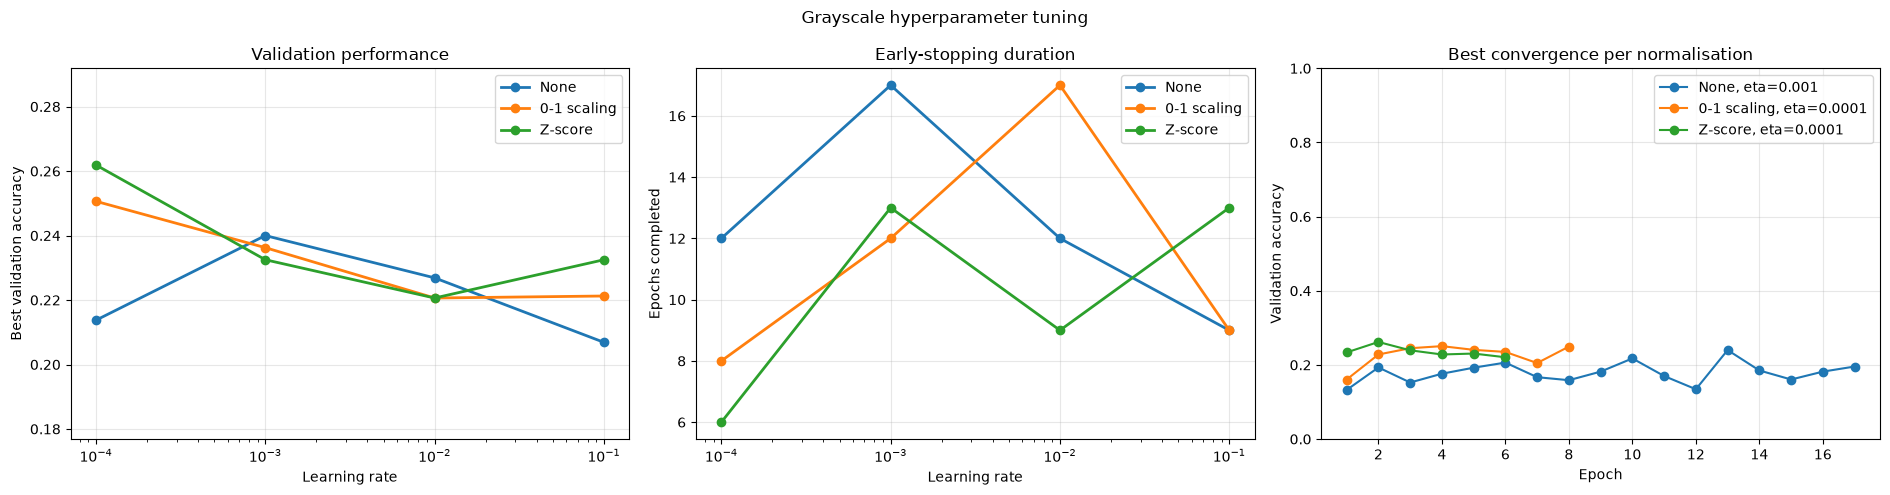

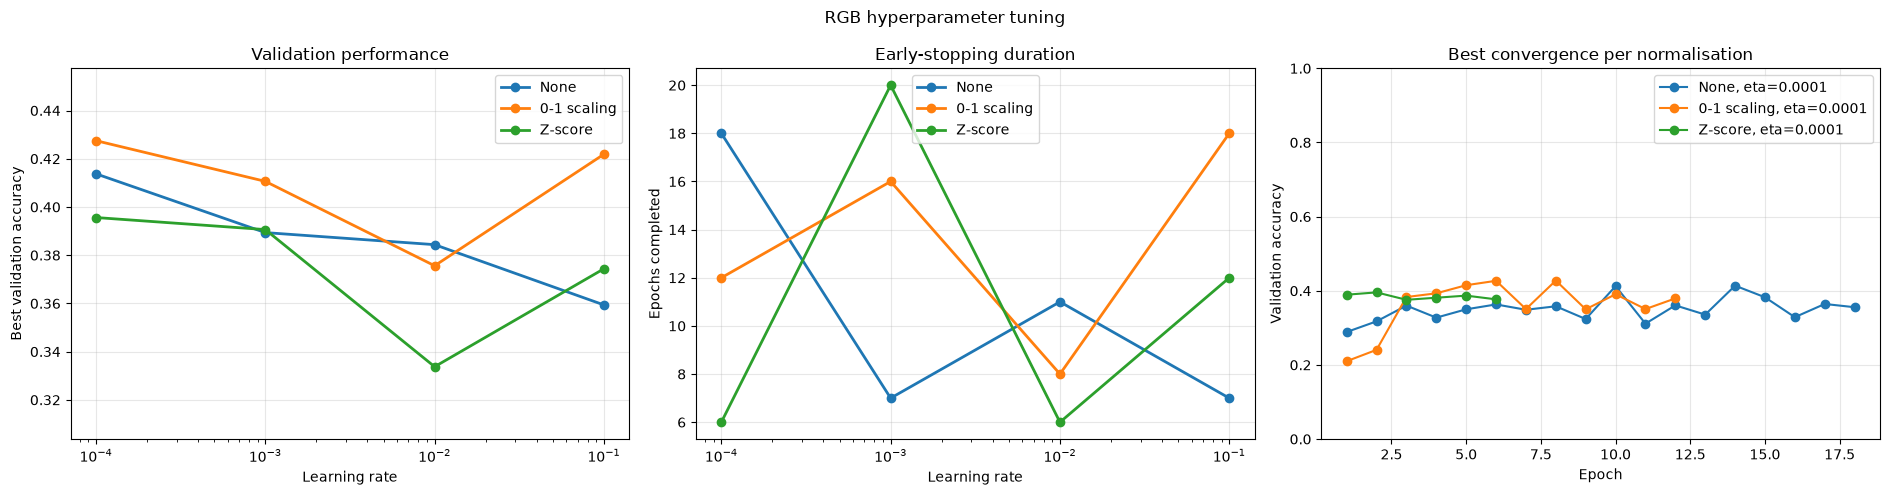

In [57]:
def best_result(results):
    """Select highest validation accuracy; break ties using fewer epochs."""
    return max(
        results,
        key=lambda result: (
            result["best_validation_accuracy"],
            -result["epochs_completed"],
        ),
    )


def plot_tuning_results(results, modality_name):
    """Visualise grid performance and validation convergence."""
    fig, axes = plt.subplots(1, 3, figsize=(19, 5))

    all_accuracies = [
        result["best_validation_accuracy"]
        for result in results
    ]

    for method in NORMALISATION_METHODS:
        method_results = [
            result for result in results
            if result["normalisation"] == method
        ]
        method_results.sort(
            key=lambda result: result["learning_rate"]
        )

        rates = [
            result["learning_rate"]
            for result in method_results
        ]
        accuracies = [
            result["best_validation_accuracy"]
            for result in method_results
        ]
        epochs_completed = [
            result["epochs_completed"]
            for result in method_results
        ]

        axes[0].plot(
            rates,
            accuracies,
            marker="o",
            linewidth=2,
            label=NORMALISATION_LABELS[method],
        )

        axes[1].plot(
            rates,
            epochs_completed,
            marker="o",
            linewidth=2,
            label=NORMALISATION_LABELS[method],
        )

        strongest_for_method = best_result(method_results)
        history = strongest_for_method["history"]

        axes[2].plot(
            history["epoch"],
            history["validation_accuracy"],
            marker="o",
            label=(
                f"{NORMALISATION_LABELS[method]}, "
                f"eta={strongest_for_method['learning_rate']:g}"
            ),
        )

    for axis in axes[:2]:
        axis.set_xscale("log")
        axis.set_xlabel("Learning rate")
        axis.grid(alpha=0.3)
        axis.legend()

    accuracy_min = max(0.0, min(all_accuracies) - 0.03)
    accuracy_max = min(1.0, max(all_accuracies) + 0.03)

    axes[0].set_ylabel("Best validation accuracy")
    axes[0].set_ylim(accuracy_min, accuracy_max)
    axes[0].set_title("Validation performance")

    axes[1].set_ylabel("Epochs completed")
    axes[1].set_title("Early-stopping duration")

    axes[2].set_xlabel("Epoch")
    axes[2].set_ylabel("Validation accuracy")
    axes[2].set_ylim(0.0, 1.0)
    axes[2].set_title("Best convergence per normalisation")
    axes[2].grid(alpha=0.3)
    axes[2].legend()

    fig.suptitle(f"{modality_name} hyperparameter tuning")
    plt.tight_layout()
    plt.show()


plot_tuning_results(gray_tuning_results, "Grayscale")
plot_tuning_results(rgb_tuning_results, "RGB")

## 4.7 Selecting the two final configurations

The winning configuration for each modality is the one with the greatest validation accuracy. No test result participates in this decision.

The selected model in each result dictionary has already been restored to its best validation epoch by the early-stopping training function. Task 5 will use the saved normalisation method and learning rate to prepare and evaluate the validation and test sets consistently.

In [58]:
best_gray_result = best_result(gray_tuning_results)
best_rgb_result = best_result(rgb_tuning_results)

best_gray_model = best_gray_result["model"]
best_rgb_model = best_rgb_result["model"]

best_gray_normalisation = best_gray_result["normalisation"]
best_rgb_normalisation = best_rgb_result["normalisation"]

best_gray_learning_rate = best_gray_result["learning_rate"]
best_rgb_learning_rate = best_rgb_result["learning_rate"]


def print_best_configuration(result):
    print(f"{result['modality']} best configuration")
    print(
        "  Normalisation:       ",
        NORMALISATION_LABELS[result["normalisation"]],
    )
    print(
        f"  Learning rate:        "
        f"{result['learning_rate']:g}"
    )
    print(
        f"  Validation accuracy:  "
        f"{result['best_validation_accuracy']:.4f}"
    )
    print(
        f"  Best epoch:           "
        f"{result['best_epoch']}"
    )
    print(
        f"  Epochs completed:     "
        f"{result['epochs_completed']}"
    )


print_best_configuration(best_gray_result)
print()
print_best_configuration(best_rgb_result)

Grayscale best configuration
  Normalisation:        Z-score
  Learning rate:        0.0001
  Validation accuracy:  0.2619
  Best epoch:           2
  Epochs completed:     6

RGB best configuration
  Normalisation:        0-1 scaling
  Learning rate:        0.0001
  Validation accuracy:  0.4275
  Best epoch:           8
  Epochs completed:     12


## Task 4 summary

This section performs a systematic and reproducible grid search for grayscale and RGB independently. It varies four learning rates and all three required normalisation methods, yielding twelve configurations per modality.

The exact tables and plots above provide the evidence for discussing:

- Which learning rate was most effective for each input scale.
- Whether normalisation improved validation accuracy.
- Which configurations converged quickly or fluctuated across epochs.
- Whether the best RGB and grayscale settings differ.

Only validation accuracy is used to select the final grayscale and RGB models. Task 5 will evaluate these selected models on the validation and untouched test sets.

# Task 5: Final model evaluation

Hyperparameter tuning is complete, so the selected grayscale and RGB models can now be evaluated on both validation and test data.

This section reports:

- Overall accuracy.
- Macro-averaged and weighted precision, recall, and F1.
- One-vs-rest accuracy, precision, recall, and F1 for every character.
- Confusion matrices for both modalities and both evaluation sets.
- The most frequent test-set confusion pairs.

The test set is used only after the models and hyperparameters have been selected. The results in this section must be reported honestly and must not be used to retune either model.

## 5.1 Evaluation measures

For each class, the ten-class problem is viewed temporarily as that character versus all other characters:

- Precision asks: of the images predicted as this character, what proportion was correct?
- Recall asks: of the real images of this character, what proportion was found?
- F1 is the harmonic mean of precision and recall.
- Per-class accuracy counts both correct positive and correct negative decisions in the one-vs-rest view.

Because per-class accuracy includes the many true negatives from the other nine classes, it can appear high even when recall is modest. Precision, recall, F1, and the confusion matrix are therefore essential for understanding each character.

Macro averages give every character equal weight. Weighted averages account for the number of examples belonging to each character.

In [ ]:
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    confusion_matrix,
    precision_recall_fscore_support,
)

DISPLAY_CLASS_NAMES = [
    "Bart",
    "Burns",
    "Homer",
    "Krusty",
    "Lisa",
    "Marge",
    "Milhouse",
    "Moe",
    "Ned",
    "Skinner",
]

## 5.2 Applying the selected preprocessing

Each selected model must receive data transformed in exactly the same way as its training data.

The preprocessing statistics for z-score normalisation are calculated from the training set only. Validation and test images are transformed with those training statistics, ensuring that no information leaks from either evaluation set.

The assertions confirm that the reconstructed validation features reproduce the validation accuracies used to select the two models.

In [ ]:
(
    X_gray_train_final,
    X_gray_validation_final,
    X_gray_test_final,
) = preprocess_splits(
    X_gray_train_raw,
    X_gray_validation_raw,
    X_gray_test_raw,
    method=best_gray_normalisation,
)

(
    X_rgb_train_final,
    X_rgb_validation_final,
    X_rgb_test_final,
) = preprocess_splits(
    X_rgb_train_raw,
    X_rgb_validation_raw,
    X_rgb_test_raw,
    method=best_rgb_normalisation,
)

gray_reproduced_validation_accuracy = classification_accuracy(
    best_gray_model,
    X_gray_validation_final,
    y_validation,
)

rgb_reproduced_validation_accuracy = classification_accuracy(
    best_rgb_model,
    X_rgb_validation_final,
    y_validation,
)

assert np.isclose(
    gray_reproduced_validation_accuracy,
    best_gray_result["best_validation_accuracy"],
)

assert np.isclose(
    rgb_reproduced_validation_accuracy,
    best_rgb_result["best_validation_accuracy"],
)

print("Selected preprocessing reproduced both validation results.")
print("Grayscale test features:", X_gray_test_final.shape)
print("RGB test features:      ", X_rgb_test_final.shape)

## 5.3 Computing overall and per-class metrics

The following function freezes one trained model, produces all predictions, and calculates its metrics. Labels 0 through 9 are supplied explicitly so every character is included even if a model never predicts one of them.

A zero precision or recall is reported as zero rather than generating a division warning.

In [ ]:
def evaluate_model(model, X, y, modality, split_name):
    """Return predictions and complete multi-class evaluation metrics."""
    labels = np.arange(len(CLASS_NAMES))
    predictions = model.predict_many(X)

    overall_accuracy = accuracy_score(y, predictions)

    macro_precision, macro_recall, macro_f1, _ = (
        precision_recall_fscore_support(
            y,
            predictions,
            labels=labels,
            average="macro",
            zero_division=0,
        )
    )

    weighted_precision, weighted_recall, weighted_f1, _ = (
        precision_recall_fscore_support(
            y,
            predictions,
            labels=labels,
            average="weighted",
            zero_division=0,
        )
    )

    (
        class_precision,
        class_recall,
        class_f1,
        class_support,
    ) = precision_recall_fscore_support(
        y,
        predictions,
        labels=labels,
        average=None,
        zero_division=0,
    )

    matrix = confusion_matrix(
        y,
        predictions,
        labels=labels,
    )

    # One-vs-rest accuracy for every class: (TP + TN) / all examples.
    true_positive = np.diag(matrix)
    false_negative = matrix.sum(axis=1) - true_positive
    false_positive = matrix.sum(axis=0) - true_positive
    true_negative = (
        matrix.sum()
        - true_positive
        - false_negative
        - false_positive
    )
    class_accuracy = (
        true_positive + true_negative
    ) / matrix.sum()

    return {
        "modality": modality,
        "split": split_name,
        "predictions": predictions,
        "accuracy": float(overall_accuracy),
        "macro_precision": float(macro_precision),
        "macro_recall": float(macro_recall),
        "macro_f1": float(macro_f1),
        "weighted_precision": float(weighted_precision),
        "weighted_recall": float(weighted_recall),
        "weighted_f1": float(weighted_f1),
        "class_accuracy": class_accuracy,
        "class_precision": class_precision,
        "class_recall": class_recall,
        "class_f1": class_f1,
        "class_support": class_support,
        "confusion_matrix": matrix,
    }


def print_evaluation_results(result):
    """Print overall and per-character measurements."""
    print(f"\n{result['modality']} - {result['split']}")
    print("=" * 70)
    print(f"Overall accuracy:      {result['accuracy']:.4f}")
    print(f"Macro precision:       {result['macro_precision']:.4f}")
    print(f"Macro recall:          {result['macro_recall']:.4f}")
    print(f"Macro F1:              {result['macro_f1']:.4f}")
    print(f"Weighted precision:    {result['weighted_precision']:.4f}")
    print(f"Weighted recall:       {result['weighted_recall']:.4f}")
    print(f"Weighted F1:           {result['weighted_f1']:.4f}")

    header = (
        f"\n{'Character':12s} "
        f"{'Support':>8s} "
        f"{'OvR acc.':>10s} "
        f"{'Precision':>10s} "
        f"{'Recall':>9s} "
        f"{'F1':>9s}"
    )
    print(header)
    print("-" * len(header))

    for class_index, class_name in enumerate(DISPLAY_CLASS_NAMES):
        print(
            f"{class_name:12s} "
            f"{result['class_support'][class_index]:8d} "
            f"{result['class_accuracy'][class_index]:10.4f} "
            f"{result['class_precision'][class_index]:10.4f} "
            f"{result['class_recall'][class_index]:9.4f} "
            f"{result['class_f1'][class_index]:9.4f}"
        )

## 5.4 Validation and test results

The same evaluation procedure is applied to four combinations:

1. Grayscale validation.
2. Grayscale test.
3. RGB validation.
4. RGB test.

The validation values show the performance used during model selection. The test values provide the final estimate of generalisation to untouched images.

In [ ]:
gray_validation_evaluation = evaluate_model(
    best_gray_model,
    X_gray_validation_final,
    y_validation,
    modality="Grayscale",
    split_name="Validation",
)

gray_test_evaluation = evaluate_model(
    best_gray_model,
    X_gray_test_final,
    y_test,
    modality="Grayscale",
    split_name="Test",
)

rgb_validation_evaluation = evaluate_model(
    best_rgb_model,
    X_rgb_validation_final,
    y_validation,
    modality="RGB",
    split_name="Validation",
)

rgb_test_evaluation = evaluate_model(
    best_rgb_model,
    X_rgb_test_final,
    y_test,
    modality="RGB",
    split_name="Test",
)

all_final_evaluations = [
    gray_validation_evaluation,
    gray_test_evaluation,
    rgb_validation_evaluation,
    rgb_test_evaluation,
]

for evaluation in all_final_evaluations:
    print_evaluation_results(evaluation)

## 5.5 Confusion matrices

In each matrix:

- A row represents the true character.
- A column represents the predicted character.
- The diagonal contains correct classifications.
- Off-diagonal cells show specific misclassifications.

A strong classifier produces large values along the diagonal and comparatively small values elsewhere.

In [ ]:
def plot_confusion_matrix_grid(evaluations):
    """Plot count-based confusion matrices for four evaluations."""
    fig, axes = plt.subplots(2, 2, figsize=(20, 18))

    for result, axis in zip(evaluations, axes.ravel()):
        display = ConfusionMatrixDisplay(
            confusion_matrix=result["confusion_matrix"],
            display_labels=DISPLAY_CLASS_NAMES,
        )
        display.plot(
            ax=axis,
            cmap="Blues",
            colorbar=False,
            values_format="d",
            xticks_rotation=45,
        )
        axis.set_title(
            f"{result['modality']} - {result['split']}"
        )

    fig.suptitle(
        "Final model confusion matrices",
        fontsize=16,
        y=1.01,
    )
    plt.tight_layout()
    plt.show()


plot_confusion_matrix_grid(all_final_evaluations)

## 5.6 Test-set confusion highlights

The confusion matrices contain one hundred cells each, so this helper extracts useful starting points for interpretation:

- The class with the highest recall is the most reliably found character.
- The class with the lowest recall is the most frequently missed character.
- The largest off-diagonal pairs identify the most common specific mistakes.

Task 6 will compare these patterns between grayscale and RGB and relate the differences to colour information.

In [ ]:
def print_confusion_highlights(result, top_n=5):
    """Print reliable classes and the largest off-diagonal mistakes."""
    recalls = result["class_recall"]
    strongest_index = int(np.argmax(recalls))
    weakest_index = int(np.argmin(recalls))

    print(f"\n{result['modality']} - {result['split']} highlights")
    print(
        "Highest recall: "
        f"{DISPLAY_CLASS_NAMES[strongest_index]} "
        f"({recalls[strongest_index]:.4f})"
    )
    print(
        "Lowest recall:  "
        f"{DISPLAY_CLASS_NAMES[weakest_index]} "
        f"({recalls[weakest_index]:.4f})"
    )
    print("Largest confusion pairs:")

    off_diagonal = result["confusion_matrix"].copy()
    np.fill_diagonal(off_diagonal, 0)

    flat_indices = np.argsort(
        off_diagonal,
        axis=None,
    )[::-1]

    pairs_printed = 0
    for flat_index in flat_indices:
        true_index, predicted_index = np.unravel_index(
            flat_index,
            off_diagonal.shape,
        )
        count = int(off_diagonal[true_index, predicted_index])

        if count == 0:
            break

        true_total = int(
            result["confusion_matrix"][true_index].sum()
        )
        percentage = count / true_total

        print(
            f"  True {DISPLAY_CLASS_NAMES[true_index]:9s} "
            f"predicted as {DISPLAY_CLASS_NAMES[predicted_index]:9s}: "
            f"{count:3d} ({percentage:.1%})"
        )

        pairs_printed += 1
        if pairs_printed == top_n:
            break


print_confusion_highlights(gray_test_evaluation)
print_confusion_highlights(rgb_test_evaluation)

## Task 5 summary

The final grayscale and RGB models have now been evaluated using overall and per-character metrics on both validation and test data.

The printed results and confusion matrices provide the evidence needed to determine:

- How closely test accuracy matches validation accuracy.
- Whether RGB maintains its validation advantage on untouched test images.
- Which characters achieve the highest and lowest precision, recall, and F1.
- Which specific pairs are confused most frequently.
- Whether colour reduces particular grayscale confusions.

These results will be interpreted directly in Task 6. No hyperparameters will be changed in response to the test results.